# Подготовка данных и инструментов

## Загрузка и обработка данных

In [83]:
from pathlib import Path
import sys, os

REPO_DIR = '/content/Multiclass_prediction_of_obesity_risk'
REPO_URL = 'https://github.com/AlexTilta/Multiclass_prediction_of_obesity_risk.git'

if not os.path.isdir(REPO_DIR):
    print("Репозиторий не найден. Клонирование и установка зависимостей...")
    !git clone {REPO_URL}

    !pip -q install -r {REPO_DIR}/requirements.txt
else:
    print(f"Репозиторий '{REPO_DIR}' уже склонирован.")

%cd {REPO_DIR}

if str(Path.cwd()) not in sys.path:
    sys.path.insert(0, str(Path.cwd()))


from src.utils import load_csv

# 3.2 Загрузка данных
df_original = load_csv('prepared_data.csv', 'data')
df_original.head()

Репозиторий '/content/Multiclass_prediction_of_obesity_risk' уже склонирован.
/content/Multiclass_prediction_of_obesity_risk


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad,BMI
0,Female,21.0,1.62,64.0,yes,no,Sometimes,3,Sometimes,no,1-2,no,0,3-5,no,Public_Transportation,Normal_Weight,24.386526
1,Female,21.0,1.52,56.0,yes,no,Always,3,Sometimes,yes,>2,yes,4-5,0-2,Sometimes,Public_Transportation,Normal_Weight,24.238227
2,Male,23.0,1.80,77.0,yes,no,Sometimes,3,Sometimes,no,1-2,no,2-4,3-5,Frequently,Public_Transportation,Normal_Weight,23.765432
3,Male,27.0,1.80,87.0,no,no,Always,3,Sometimes,no,1-2,no,2-4,0-2,Frequently,Walking,Overweight,26.851852
4,Male,22.0,1.78,89.8,no,no,Sometimes,1-2,Sometimes,no,1-2,no,0,0-2,Sometimes,Public_Transportation,Overweight,28.342381


 ## Установка библиотек

In [84]:
!pip show catboost || pip install catboost
!pip show phik || pip install phik

Name: catboost
Version: 1.2.8
Summary: CatBoost Python Package
Home-page: https://catboost.ai
Author: CatBoost Developers
Author-email: 
License: Apache License, Version 2.0
Location: /usr/local/lib/python3.12/dist-packages
Requires: graphviz, matplotlib, numpy, pandas, plotly, scipy, six
Required-by: 
Name: phik
Version: 0.12.5
Summary: Phi_K correlation analyzer library
Home-page: 
Author: 
Author-email: "KPMG N.V. The Netherlands" <kave@kpmg.com>
License: 
Location: /usr/local/lib/python3.12/dist-packages
Requires: joblib, matplotlib, numpy, pandas, scipy
Required-by: 


## Библиотеки

In [85]:
# Общие библиотеки
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt

from sklearn.model_selection import (
    train_test_split, GridSearchCV, StratifiedKFold, cross_val_predict
)
from sklearn.preprocessing import (
    StandardScaler, LabelEncoder, PolynomialFeatures
)
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score
)

# Утилиты
import joblib
import warnings
warnings.filterwarnings('ignore')
from phik import phik_matrix


# Библиотеки моделей или для конкретных моделей
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import (
    RandomForestClassifier, StackingClassifier
)
from catboost import CatBoostClassifier, Pool, cv

# Настройка датасета

## Константы (для отчетов и редактирования наименований признаков)

In [86]:
# Настройка целевых переменных
TARGET_COLUMN = 'NObeyesdad'
COLUMNS_TO_DROP = ['BMI']

## Преобразование данных для большинство моделей(кроме CatBoost. У него есть Pool)

In [87]:
df_transformed = df_original.copy()

caec_calc_map = {'no': 0, 'Sometimes': 1, 'Frequently': 2, 'Always': 3}
df_transformed['CAEC'] = df_transformed['CAEC'].replace(caec_calc_map)
df_transformed['CALC'] = df_transformed['CALC'].replace(caec_calc_map)

fcvc_map = {'no': 0, 'Sometimes': 1, 'Always': 2}
df_transformed['FCVC'] = df_transformed['FCVC'].replace(fcvc_map)

ncp_map = {'1-2': 1.5, '3': 3.0, '>3': 3.5}
df_transformed['NCP'] = df_transformed['NCP'].replace(ncp_map)

ch2o_map = {'<1': 0.5, 'Sometimes': 1.0, '1-2': 1.5, '>2': 3.0}
df_transformed['CH2O'] = df_transformed['CH2O'].replace(ch2o_map)

faf_tue_map = {'0': 0, 'no': 0, '0-2': 1, '1-2': 1, '2-4': 3,
               '3-5': 4, '4-5': 4, '>5': 5}
df_transformed['FAF'] = df_transformed['FAF'].replace(faf_tue_map)
df_transformed['TUE'] = df_transformed['TUE'].replace(faf_tue_map)

yes_no_map = {'yes': 1.0, 'no': 0.0}
df_transformed['family_history_with_overweight'] = df_transformed['family_history_with_overweight'].replace(yes_no_map)
df_transformed['FAVC'] = df_transformed['FAVC'].replace(yes_no_map)
df_transformed['SMOKE'] = df_transformed['SMOKE'].replace(yes_no_map)
df_transformed['SCC'] = df_transformed['SCC'].replace(yes_no_map)

gender_map = {'Male': 1.0, 'Female': 0.0}
df_transformed['Gender'] = df_transformed['Gender'].replace(gender_map)

mtrans_le = LabelEncoder()
df_transformed['MTRANS'] = mtrans_le.fit_transform(df_transformed['MTRANS']).astype(float)

df = df_transformed.drop(columns=COLUMNS_TO_DROP, errors='ignore')

INT_COLUMNS = ['FCVC', 'CAEC', 'FAF', 'TUE', 'CALC']
INT_COLUMNS_ADJUSTED = [col for col in INT_COLUMNS if col in df.columns]

for col in INT_COLUMNS_ADJUSTED:
    df[col] = df[col].astype('Int64')

EXCLUDE_COLUMNS = [TARGET_COLUMN] + INT_COLUMNS_ADJUSTED

COLUMNS_TO_FLOAT = [col for col in df.columns if col not in EXCLUDE_COLUMNS]

for col in COLUMNS_TO_FLOAT:
    try:
        df[col] = df[col].astype(float)
    except Exception as e:
        pass

print(df.dtypes)
df

Gender                            float64
Age                               float64
Height                            float64
Weight                            float64
family_history_with_overweight    float64
FAVC                              float64
FCVC                                Int64
NCP                               float64
CAEC                                Int64
SMOKE                             float64
CH2O                              float64
SCC                               float64
FAF                                 Int64
TUE                                 Int64
CALC                                Int64
MTRANS                            float64
NObeyesdad                         object
dtype: object


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,0.0,21.000000,1.620000,64.000000,1.0,0.0,1,3.0,1,0.0,1.5,0.0,0,4,0,3.0,Normal_Weight
1,0.0,21.000000,1.520000,56.000000,1.0,0.0,2,3.0,1,1.0,3.0,1.0,4,1,1,3.0,Normal_Weight
2,1.0,23.000000,1.800000,77.000000,1.0,0.0,1,3.0,1,0.0,1.5,0.0,3,4,2,3.0,Normal_Weight
3,1.0,27.000000,1.800000,87.000000,0.0,0.0,2,3.0,1,0.0,1.5,0.0,3,1,2,4.0,Overweight
4,1.0,22.000000,1.780000,89.800000,0.0,0.0,1,1.5,1,0.0,1.5,0.0,0,1,1,3.0,Overweight
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2082,0.0,20.976842,1.710730,131.408528,1.0,1.0,2,3.0,1,0.0,1.5,0.0,3,4,1,3.0,Obesity
2083,0.0,21.982942,1.748584,133.742943,1.0,1.0,2,3.0,1,0.0,1.5,0.0,1,4,1,3.0,Obesity
2084,0.0,22.524036,1.752206,133.689352,1.0,1.0,2,3.0,1,0.0,1.5,0.0,1,4,1,3.0,Obesity
2085,0.0,24.361936,1.739450,133.346641,1.0,1.0,2,3.0,1,0.0,3.0,0.0,1,4,1,3.0,Obesity


# Общие объявления и функции для моделей

In [94]:
x = df.drop(TARGET_COLUMN, axis=1)
y = df[TARGET_COLUMN]

X_train, X_test, y_train, y_test = train_test_split(x, y, random_state=42, stratify=y)

In [97]:
def make_model(pipeline, x, y):
    stratified_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    y_pred_cv_full = cross_val_predict(estimator=pipeline,
                                       X=x,
                                       y=y,
                                       cv=stratified_kfold,
                                       n_jobs=-1)

    class_names = [str(c) for c in sorted(y.unique())]

    print("Classification Report - Full Model CV:")
    print(classification_report(y, y_pred_cv_full, target_names=class_names))

    cm = confusion_matrix(y, y_pred_cv_full)

    plt.figure(figsize=(10, 8))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names
    )

    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix - Full Model CV')
    plt.show()

# Логистическая регрессия

Classification Report - Full Model CV:
                     precision    recall  f1-score   support

Insufficient_Weight       0.90      0.98      0.94       200
      Normal_Weight       0.90      0.71      0.79       212
            Obesity       0.99      0.99      0.99       729
         Overweight       0.90      0.96      0.93       424

           accuracy                           0.94      1565
          macro avg       0.92      0.91      0.91      1565
       weighted avg       0.94      0.94      0.94      1565



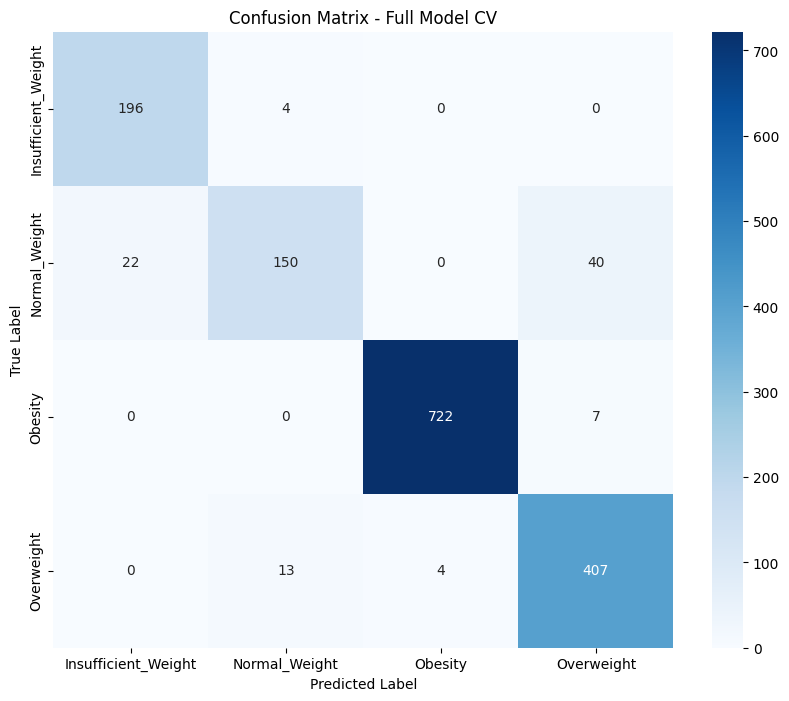

In [100]:
logreg_pipeline = make_pipeline(
    StandardScaler(),
    LogisticRegression(random_state=42)
)
make_model(logreg_pipeline, X_train, y_train)

# SVM

Classification Report - Full Model CV:
                     precision    recall  f1-score   support

Insufficient_Weight       0.92      0.99      0.95       200
      Normal_Weight       0.98      0.84      0.91       212
            Obesity       1.00      0.99      0.99       729
         Overweight       0.95      0.99      0.97       424

           accuracy                           0.97      1565
          macro avg       0.96      0.95      0.96      1565
       weighted avg       0.97      0.97      0.97      1565



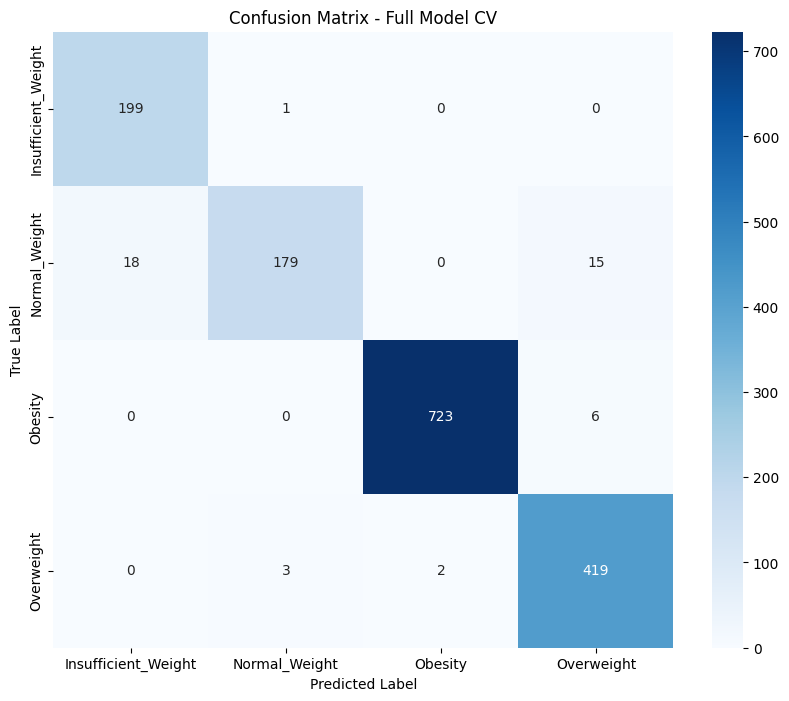

In [101]:
svm_pipeline = make_pipeline(
        StandardScaler(),
        SVC(kernel='linear', random_state=42)
    )
make_model(svm_pipeline, X_train, y_train)

# Random Forest

Classification Report - Full Model CV:
                     precision    recall  f1-score   support

Insufficient_Weight       0.94      0.94      0.94       200
      Normal_Weight       0.84      0.80      0.82       212
            Obesity       0.99      0.99      0.99       729
         Overweight       0.91      0.94      0.93       424

           accuracy                           0.95      1565
          macro avg       0.92      0.92      0.92      1565
       weighted avg       0.94      0.95      0.94      1565



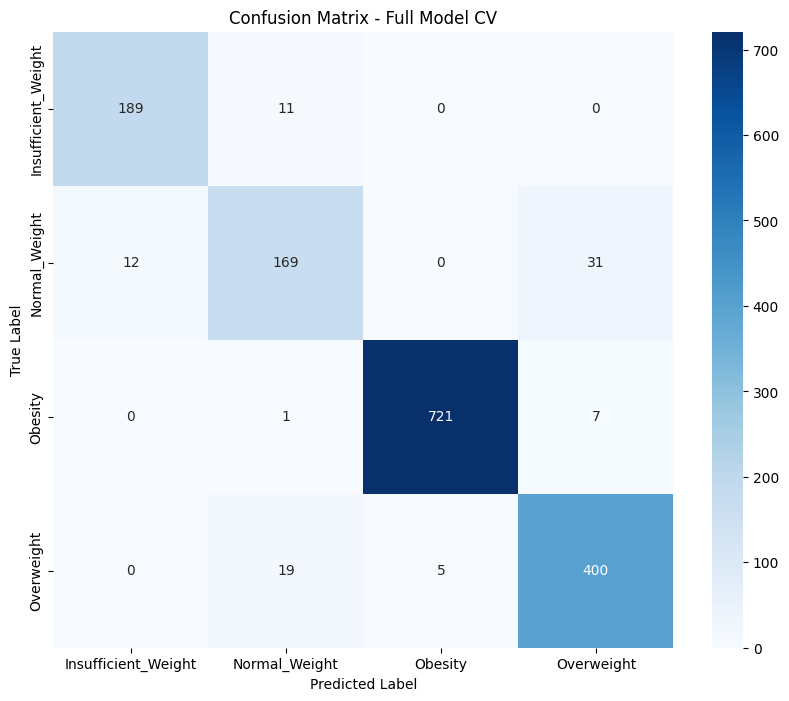

In [102]:
rf_pipeline = make_pipeline(
    RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
)
make_model(rf_pipeline, X_train, y_train)

# Дерево решений

Classification Report - Full Model CV:
                     precision    recall  f1-score   support

Insufficient_Weight       0.92      0.98      0.95       200
      Normal_Weight       0.89      0.82      0.85       212
            Obesity       0.99      0.99      0.99       729
         Overweight       0.93      0.94      0.94       424

           accuracy                           0.95      1565
          macro avg       0.93      0.93      0.93      1565
       weighted avg       0.95      0.95      0.95      1565



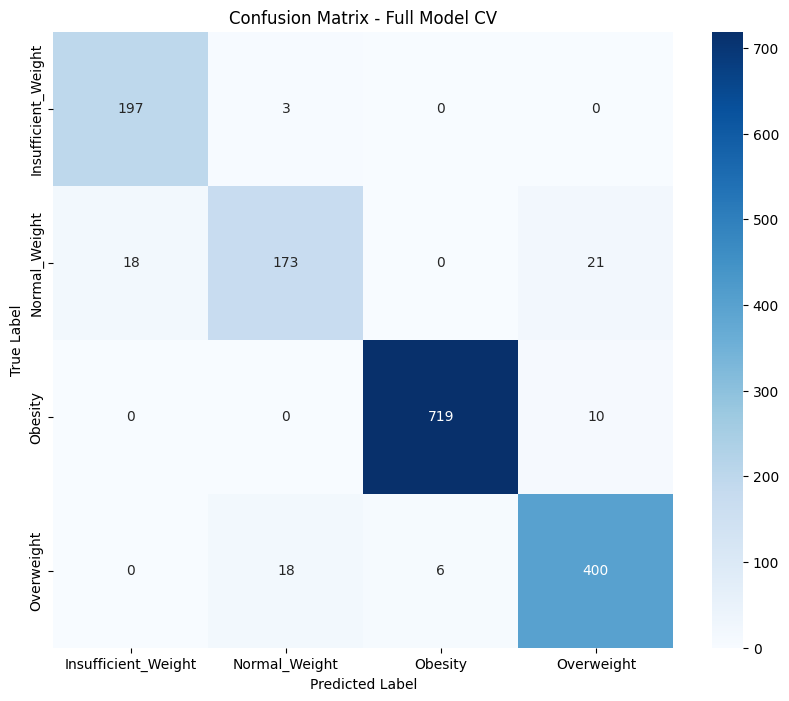

In [103]:
dt_pipeline = make_pipeline(
    DecisionTreeClassifier(random_state=42)
)
make_model(dt_pipeline, X_train, y_train)

# Стекинг